In [32]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy
import hvplot.xarray
import hvplot

In [45]:
ds_9th = xr.load_dataset('../data/TEC_geospatial_data/gps240509g.002.nc')

In [46]:
ds_9th

<xarray.Dataset> Size: 299MB
Dimensions:     (timestamps: 288, gdlat: 180, glon: 360)
Coordinates:
  * timestamps  (timestamps) float64 2kB 1.715e+09 1.715e+09 ... 1.715e+09
  * gdlat       (gdlat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0
  * glon        (glon) float64 3kB -180.0 -179.0 -178.0 ... 177.0 178.0 179.0
Data variables:
    dtec        (timestamps, gdlat, glon) float64 149MB nan nan nan ... nan nan
    tec         (timestamps, gdlat, glon) float64 149MB nan nan nan ... nan nan
Attributes: (12/16)
    catalog_text:          Catalog information from record 0:                ...
    header_text:           Header information from record 1:                 ...
    instrument:            World-wide GNSS Receiver Network
    instrument_code:       8000
    kind_of_data_file:     TEC binned 1 degree by 1 degree by 5 min
    kindat_code:           3500
    ...                    ...
    instrument_latitude:   0.0
    instrument_longitude:  0.0
    instrument_altitude:   0.0
    instrument_category:   Distributed Ground Based Satellite Receivers
    instrument_PI:         Anthea Coster
    instrument_PI_email:   acoster@haystack.mit.edu

In [34]:
ds_10th = xr.load_dataset('../data/TEC_geospatial_data/gps240510g.003.nc')
# thanks to james for this
# converting the timestamps variable to normal date times
new_datetime = np.array(ds_10th.timestamps.values.astype(np.int64), dtype='datetime64[s]')
ds_10th['timestamps'] = new_datetime
ds_10th = ds_10th.rename({'timestamps': 'time'})

In [35]:
# select for all tec data lat and long at a specific time
ds_10th.tec.sel(time='2024-05-10T22:00:00').glon[1:181]

<xarray.DataArray 'glon' (glon: 180)> Size: 1kB
array([-179., -178., -177., -176., -175., -174., -173., -172., -171., -170.,
       -169., -168., -167., -166., -165., -164., -163., -162., -161., -160.,
       -159., -158., -157., -156., -155., -154., -153., -152., -151., -150.,
       -149., -148., -147., -146., -145., -144., -143., -142., -141., -140.,
       -139., -138., -137., -136., -135., -134., -133., -132., -131., -130.,
       -129., -128., -127., -126., -125., -124., -123., -122., -121., -120.,
       -119., -118., -117., -116., -115., -114., -113., -112., -111., -110.,
       -109., -108., -107., -106., -105., -104., -103., -102., -101., -100.,
        -99.,  -98.,  -97.,  -96.,  -95.,  -94.,  -93.,  -92.,  -91.,  -90.,
        -89.,  -88.,  -87.,  -86.,  -85.,  -84.,  -83.,  -82.,  -81.,  -80.,
        -79.,  -78.,  -77.,  -76.,  -75.,  -74.,  -73.,  -72.,  -71.,  -70.,
        -69.,  -68.,  -67.,  -66.,  -65.,  -64.,  -63.,  -62.,  -61.,  -60.,
        -59.,  -58.,  -57.,  -56.,  -55.,  -54.,  -53.,  -52.,  -51.,  -50.,
        -49.,  -48.,  -47.,  -46.,  -45.,  -44.,  -43.,  -42.,  -41.,  -40.,
        -39.,  -38.,  -37.,  -36.,  -35.,  -34.,  -33.,  -32.,  -31.,  -30.,
        -29.,  -28.,  -27.,  -26.,  -25.,  -24.,  -23.,  -22.,  -21.,  -20.,
        -19.,  -18.,  -17.,  -16.,  -15.,  -14.,  -13.,  -12.,  -11.,  -10.,
         -9.,   -8.,   -7.,   -6.,   -5.,   -4.,   -3.,   -2.,   -1.,    0.])
Coordinates:
    time     datetime64[s] 8B 2024-05-10T22:00:00
  * glon     (glon) float64 1kB -179.0 -178.0 -177.0 -176.0 ... -2.0 -1.0 0.0
Attributes:
    units:        deg
    description:  Geographic longitude of measurement

In [36]:
ds_10th.tec.sel(time='2024-05-10T22:00:00').values.shape

(180, 360)

In [37]:
print(ds_10th.gdlat.values.shape)
print(ds_10th.glon.values.shape)

(180,)
(360,)


In [38]:
# python is saying the lat and long data does not have the same shape - what is going on here??????????????????????????????????????
# the lat and long data is geodetic not geocentric - which should be ok with the transform parameter?

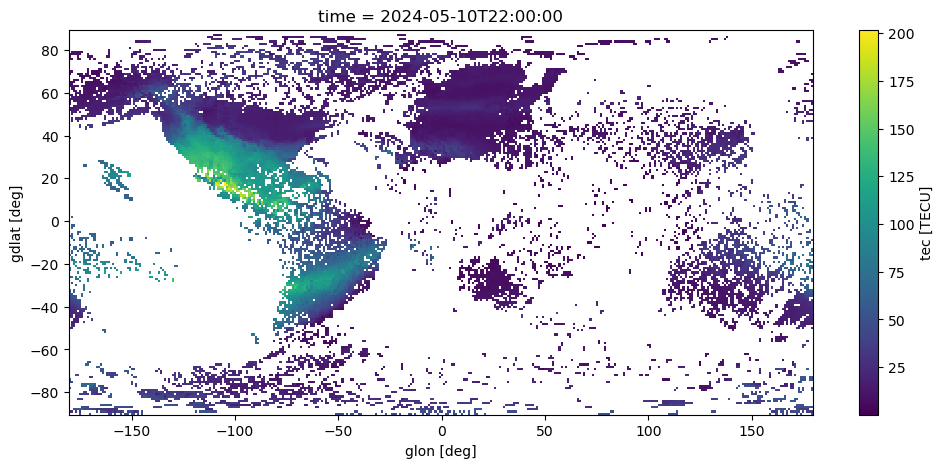

In [39]:
plt.figure(figsize=(12,5))
ds_10th.tec.sel(time='2024-05-10T22:00:00').plot()

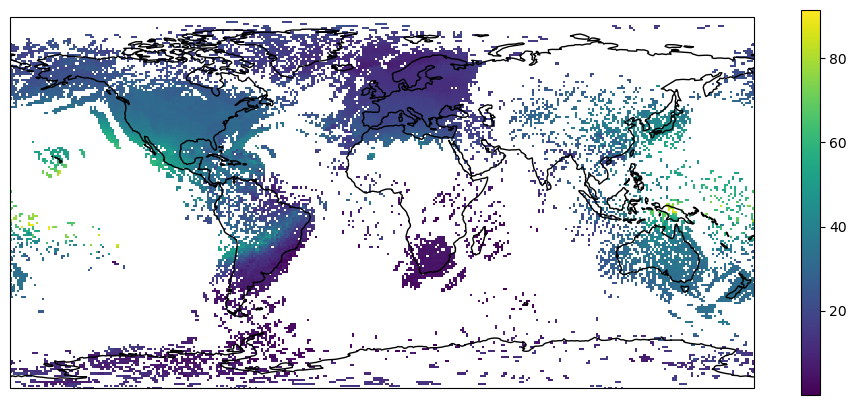

In [40]:
plt.figure(figsize=(12,5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
plt.pcolormesh(ds_10th.tec.sel(time='2024-05-10T01:00:00').glon, ds_10th.tec.sel(time='2024-05-10T01:00:00').gdlat, ds_10th.tec.sel(time='2024-05-10T01:00:00').values, transform=ccrs.PlateCarree())
plt.colorbar()
plt.show()

In [41]:
ds_10th.time

<xarray.DataArray 'time' (time: 288)> Size: 2kB
array(['2024-05-10T00:00:00', '2024-05-10T00:05:00', '2024-05-10T00:10:00',
       ..., '2024-05-10T23:45:00', '2024-05-10T23:50:00',
       '2024-05-10T23:55:00'], shape=(288,), dtype='datetime64[s]')
Coordinates:
  * time     (time) datetime64[s] 2kB 2024-05-10 ... 2024-05-10T23:55:00

In [42]:
test = ds_10th.tec.isel(time=slice(0,100)).sel(glon=slice(-150,-50), gdlat=slice(0,50))

In [47]:
test.hvplot(groupby="time", cmap='viridis', clim=(0, 100))

:DynamicMap   [time]
   :Image   [glon,gdlat]   (tec)

In [44]:
ds_10th.tec.hvplot(
    groupby="time",
    clim=(0, 100),  # adds a widget for time  # sets colorbar limits
)

:DynamicMap   [time]
   :Image   [glon,gdlat]   (tec)

In [7]:
ds_10th.tec.hvplot(groupby='time')

:DynamicMap   [time]
   :Image   [glon,gdlat]   (tec)

In [ ]:
#dates = ['2024-05-10',]

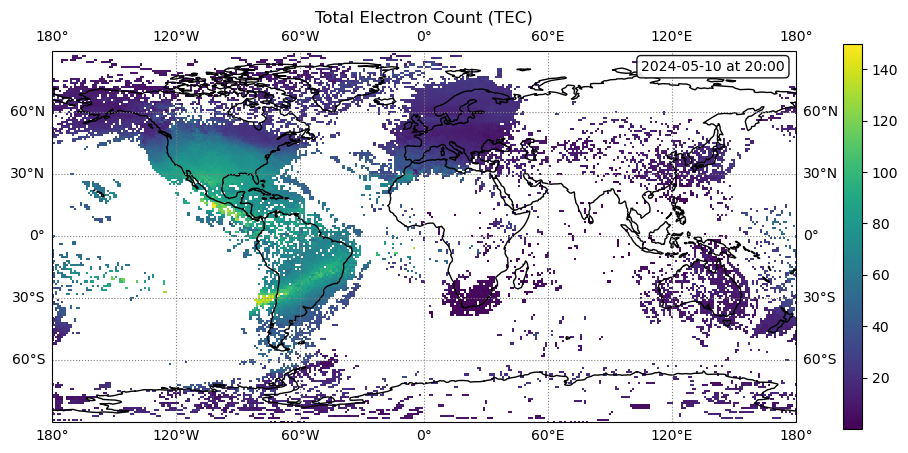

In [116]:
date = '2024-05-10'
time = '20:00'
plt.figure(figsize=(12,5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
plt.pcolormesh(ds_10th.tec.sel(time=f'{date}T{time}:00').glon, ds_10th.tec.sel(time=f'{date}T{time}:00').gdlat, ds_10th.tec.sel(time=f'{date}T{time}:00').values, transform=ccrs.PlateCarree())
plt.colorbar()
text_box = dict(boxstyle='round', facecolor='white', alpha=0.9)
plt.text(105, 80, f'{date} at {time}', bbox=text_box)
plt.title('Total Electron Count (TEC)')
ax.gridlines(draw_labels=True, linestyle=':', color='grey')
plt.show()

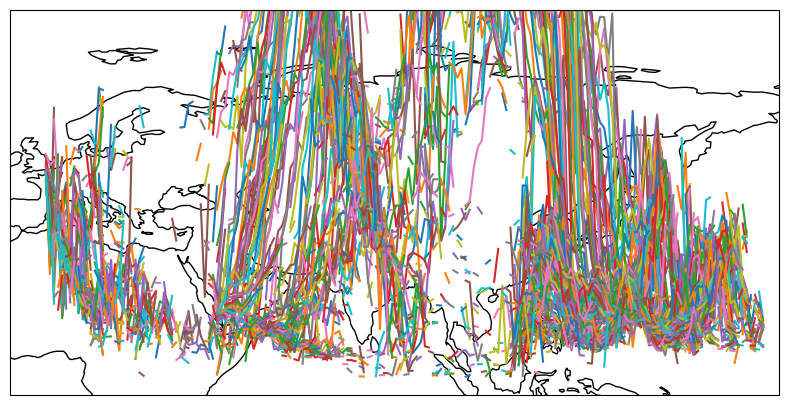

In [71]:
plt.figure(figsize=(12,5))
# using a PlateCarre projection for the map
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
#ax.scatter(ds_10th.gdlat, ds_10th.glon, c=ds_10th.tec.sel(time='2024-05-10T22:00:00'))
#ax.scatter(ds_10th.tec.sel(time='2024-05-10T22:00:00').glon[1:181], ds_10th.tec.sel(time='2024-05-10T22:00:00').gdlat, label='5901429', s=5, transform=ccrs.Geodetic())
#ax.scatter(ds_10th.tec.sel(time='2024-05-10T22:00:00').glon[180:], ds_10th.tec.sel(time='2024-05-10T22:00:00').gdlat, label='5901429', color='red', s=5, transform=ccrs.Geodetic())
ax.plot(ds_10th.tec.sel(time='2024-05-10T22:00:00'), transform=ccrs.Geodetic())
#ax.hist2d(ds_10th.tec.sel(time='2024-05-10T22:00:00').glon[1:181], ds_10th.tec.sel(time='2024-05-10T22:00:00').gdlat, bins=(500,200))

#ax.scatter()
plt.show()
# scatter plot to add points on the map
#ax.scatter(ds29.longitude, ds29.latitude, label='5901429', color='red', s=5)
#ax.scatter(ds87.longitude, ds87.latitude, label='1901487', color='purple', s=5)
#ax.stock_img() # gives coloring to the map
#ax.legend(fontsize=14)
#ax.gridlines(draw_labels=True, linestyle=':', color='grey')

In [21]:
#ds_10th.timestamps.values.astype(np.int64)

In [25]:
ds_10th.timestamps.values[0]

np.float64(1715299200.0)

In [22]:
ds_10th.timestamps.values.flatten

<function ndarray.flatten>

In [ ]:
plt.figure(figsize=(12,5))
# using a PlateCarre projection for the map
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()

ax.scatter(ds_10th.te)
ax.scatter()
# scatter plot to add points on the map
#ax.scatter(ds29.longitude, ds29.latitude, label='5901429', color='red', s=5)
#ax.scatter(ds87.longitude, ds87.latitude, label='1901487', color='purple', s=5)
#ax.stock_img() # gives coloring to the map
#ax.legend(fontsize=14)
#ax.gridlines(draw_labels=True, linestyle=':', color='grey')

In [5]:
ds_11th = xr.load_dataset('../data/TEC_geospatial_data/gps240511g.003.nc')
ds_raw

<xarray.Dataset> Size: 299MB
Dimensions:     (timestamps: 288, gdlat: 180, glon: 360)
Coordinates:
  * timestamps  (timestamps) float64 2kB 1.715e+09 1.715e+09 ... 1.715e+09
  * gdlat       (gdlat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0
  * glon        (glon) float64 3kB -180.0 -179.0 -178.0 ... 177.0 178.0 179.0
Data variables:
    dtec        (timestamps, gdlat, glon) float64 149MB nan nan nan ... nan nan
    tec         (timestamps, gdlat, glon) float64 149MB nan nan nan ... nan nan
Attributes: (12/16)
    catalog_text:          Catalog information from record 0:                ...
    header_text:           Header information from record 1:                 ...
    instrument:            World-wide GNSS Receiver Network
    instrument_code:       8000
    kind_of_data_file:     TEC binned 1 degree by 1 degree by 5 min
    kindat_code:           3500
    ...                    ...
    instrument_latitude:   0.0
    instrument_longitude:  0.0
    instrument_altitude:   0.0
    instrument_category:   Distributed Ground Based Satellite Receivers
    instrument_PI:         Anthea Coster
    instrument_PI_email:   acoster@haystack.mit.edu

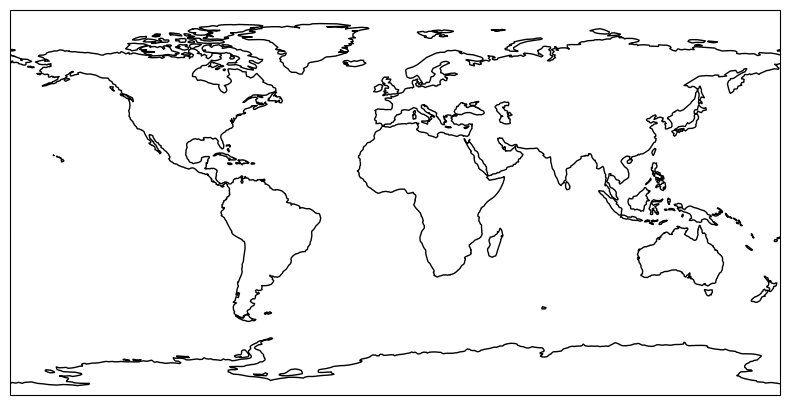

In [9]:
plt.figure(figsize=(12,5))
# using a PlateCarre projection for the map
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()

ax.scatter()

# scatter plot to add points on the map
#ax.scatter(ds29.longitude, ds29.latitude, label='5901429', color='red', s=5)
#ax.scatter(ds87.longitude, ds87.latitude, label='1901487', color='purple', s=5)
#ax.stock_img() # gives coloring to the map
#ax.legend(fontsize=14)
#ax.gridlines(draw_labels=True, linestyle=':', color='grey')

/opt/anaconda3/envs/solar_flare/lib/python3.12/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


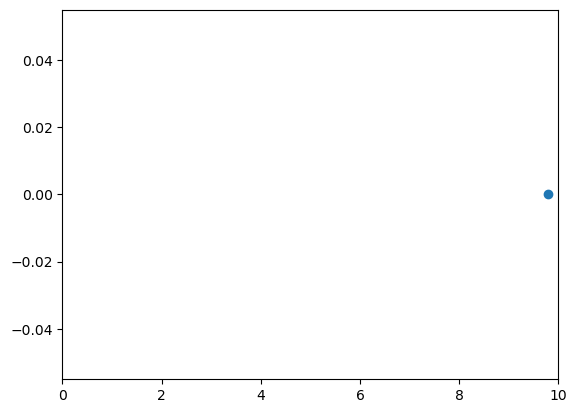

In [58]:
fig, ax = plt.subplots()
ax.set_xlim([0, 10])

scat = ax.scatter(1, 0)
x = np.linspace(0, 10)


def animate(i):
    scat.set_offsets((x[i], 0))
    return (scat,)


ani = animation.FuncAnimation(fig, animate, repeat=True, frames=len(x) - 1, interval=50)

# To save the animation using Pillow as a gif
writer = animation.PillowWriter(fps=15,
                                 metadata=dict(artist='Me'),
                                 bitrate=1800)
ani.save('scatter.gif', writer=writer)

plt.show()

MovieWriter ffmpeg unavailable; using Pillow instead.


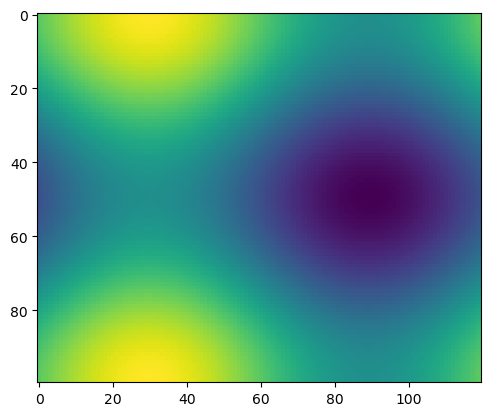

In [65]:
fig, ax = plt.subplots()


def f(x, y):
    return np.sin(x) + np.cos(y)

x = np.linspace(0, 2 * np.pi, 120)
y = np.linspace(0, 2 * np.pi, 100).reshape(-1, 1)

# ims is a list of lists, each row is a list of artists to draw in the
# current frame; here we are just animating one artist, the image, in
# each frame
ims = []
for i in range(60):
    x += np.pi / 15
    y += np.pi / 30
    im = ax.imshow(f(x, y), animated=True)
    if i == 0:
        ax.imshow(f(x, y))  # show an initial one first
    ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=50, blit=True,
                                repeat_delay=1000)

# To save the animation, use e.g.
#
ani.save("movie.gif")
#
# or
#
# writer = animation.FFMpegWriter(
#     fps=15, metadata=dict(artist='Me'), bitrate=1800)
# ani.save("movie.mp4", writer=writer)

plt.show()